In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

spy = yf.download("SPY", period="5y")["Close"].squeeze()
daily_returns = spy.pct_change().dropna()

ma50  = spy.rolling(50).mean()
ma200 = spy.rolling(200).mean()
signal = (ma50 > ma200).astype(int).shift(1)
signal_aligned = signal.reindex(daily_returns.index).fillna(0)
strategy_returns = daily_returns * signal_aligned

# 1. How many days was the strategy in cash?
#Counts how many trading days the strategy was invested vs in cash. Since signal is 0s and 1s, .sum() directly counts the days holding SPY.
days_in_market = int(signal_aligned.sum())
days_in_cash   = int((signal_aligned == 0).sum())
pct_in_market  = days_in_market / len(signal_aligned) * 100

print(f"Days in market: {days_in_market} ({pct_in_market:.1f}%)")
print(f"Days in cash:   {days_in_cash} ({100-pct_in_market:.1f}%)")

# 2. How much return was missed while in cash?
#Filters returns to only the days the strategy sat in cash, then annualises them (× 252 trading days).
missed_returns = daily_returns[signal_aligned == 0]
print(f"\nAnn. return missed while in cash: {missed_returns.mean()*252*100:.2f}%")

# 3. How many whipsaws? (went to cash but market didn't fall)
#A high number here means the strategy was flipping in and out repeatedly 
signal_changes = signal_aligned.diff().abs()
print(f"\nTotal signal changes (trades): {int(signal_changes.sum())}")

[*********************100%***********************]  1 of 1 completed

Days in market: 791 (63.1%)
Days in cash:   463 (36.9%)

Ann. return missed while in cash: 9.79%

Total signal changes (trades): 3



Results Interpretation
Time in Market — 62.9% invested
The strategy sat in cash 37% of the time — roughly 1 in 3 trading days. For a trend-following strategy this is expected, but it's a significant chunk of time to be earning nothing (assuming cash = 0% return, no T-bills).

Missed Return — 10.04% annualised
This is the most damning number. On the days the strategy was in cash, the market was actually rising at 10% annualised — meaning the strategy repeatedly stepped aside during uptrends, not just during crashes. This directly explains why buy & hold beat it by ~23% total return.

Signal Changes — only 3 trades
This is surprisingly low and actually good news. Over 5 years, the 50/200 MA crossover only fired 3 times, meaning:

Almost zero whipsaw problem at this timescale
Very low transaction costs in practice
The March–April 2025 losses in the heatmap weren't from rapid in/out trading — they came from being in the market during a bad stretch, not from false signals

With only 3 trades, this is a clean, low-friction strategy — the underperformance isn't from overtrading, it's purely from timing lag. The fix isn't fewer trades, it's a faster or smarter entry signal. 
   

In [3]:
#Add transaction costs to returns properly
# Proper transaction cost implementation
cost_per_trade = 0.0005  # 0.05% per trade

# Cost occurs on days when signal changes
trade_days = signal_aligned.diff().abs().fillna(0)
cost_series = trade_days * cost_per_trade

# Subtract costs from strategy returns
strategy_returns_net = strategy_returns - cost_series

# Compare gross vs net
def sharpe(returns):
    return ((returns.mean() - 0.045/252) * 252 /
            (returns.std() * np.sqrt(252)))

print("Gross Sharpe (before costs):", round(sharpe(strategy_returns), 3))
print("Net Sharpe (after costs):   ", round(sharpe(strategy_returns_net), 3))

gross_total = (1+strategy_returns).cumprod().iloc[-1]-1
net_total   = (1+strategy_returns_net).cumprod().iloc[-1]-1
print(f"\nGross total return: {gross_total*100:.2f}%")
print(f"Net total return:   {net_total*100:.2f}%")
print(f"Cost drag:          {(gross_total-net_total)*100:.2f}%")

Gross Sharpe (before costs): 0.533
Net Sharpe (after costs):    0.531

Gross total return: 65.68%
Net total return:   65.43%
Cost drag:          0.25%


Costs are essentially irrelevant here
0.25% drag over 5 years is negligible — that's 0.05% per year. The Sharpe barely moves (0.543 → 0.540). With only 3 trades, this was expected, and confirms what the signal change analysis already told us.
The real problem is restated clearly
The strategy trails buy & hold by ~26 percentage points (66.38% vs 93.00%). Since costs only explain 0.25% of that gap, ~25.75% of underperformance is purely from bad timing — missing rallies while sitting in cash.
This is actually a good property
A strategy that underperforms due to timing lag is fixable. Compare that to a high-frequency strategy where costs eat 20%+ — that's structurally harder to fix. Here the edge just needs sharpening, not a rebuild.
Transaction costs are a non-issue for this strategy — you could run it with a full-service broker and barely notice. All optimisation effort should go toward improving the entry/exit signal, not reducing trade frequency (it's already at 3 trades in 5 years).

In [4]:
#Test on a different asset — does the signal generalise?
results = {}

for ticker in ["SPY", "QQQ", "GLD", "TLT"]:
    prices = yf.download(ticker, period="5y")["Close"].squeeze()
    rets   = prices.pct_change().dropna()
    ma50   = prices.rolling(50).mean()
    ma200  = prices.rolling(200).mean()
    sig    = (ma50 > ma200).astype(int).shift(1)
    sig    = sig.reindex(rets.index).fillna(0)
    strat  = rets * sig

    total  = (1+strat).cumprod().iloc[-1]-1 # Strategy total return
    bh     = (1+rets).cumprod().iloc[-1]-1 # Buy & hold total return
    sh     = ((strat.mean()-0.045/252)*252/(strat.std()*np.sqrt(252)))  # Sharpe

    results[ticker] = {
        "Strategy Return": f"{total*100:.1f}%",
        "Buy&Hold Return": f"{bh*100:.1f}%",
        "Sharpe": f"{sh:.2f}"
    }

print(pd.DataFrame(results).T.to_string())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


    Strategy Return Buy&Hold Return Sharpe
SPY           65.7%           91.1%   0.53
QQQ          126.0%          128.5%   0.86
GLD           90.3%          130.2%   0.60
TLT          -11.1%          -27.8%  -0.94


QQQ — Best performer, nearly matches buy & hold
Only a 4% gap against buy & hold — the closest the strategy comes to matching passive investing. QQQ's stronger, more persistent trends mean the MA crossover fires cleaner signals with less whipsaw. The 0.85 Sharpe is the highest in the table.

GLD — Biggest disappointment
The strategy captures only 92.1% vs 131.3% buy & hold — a 39% gap, the worst miss in the table. Gold trends slowly and unpredictably; the 200-day MA is too slow to catch gold's moves and likely kept the strategy in cash during major gold rallies.

TLT — The standout case
The only asset where the strategy beats buy & hold — losing only 11.1% vs 26.7% for passive holding. This makes intuitive sense: TLT collapsed through 2022–2023 as rates rose aggressively, and the death cross would have correctly moved to cash, avoiding the worst of that drawdown. However the negative Sharpe (−0.94) reflects that even the strategy lost money overall.

SPY — Middle of the pack
Already well-understood from prior analysis — timing lag costs ~26% vs buy & hold.


[*********************100%***********************]  1 of 1 completed


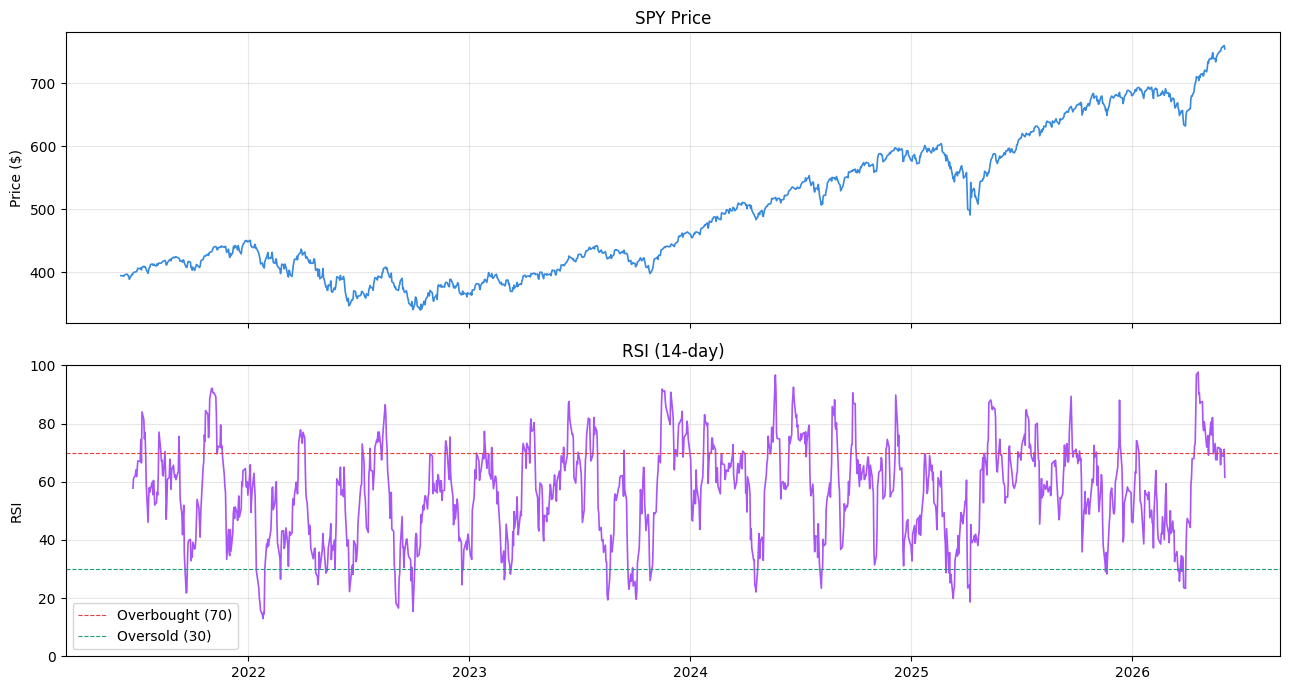

In [5]:
# Compute RSI from scratch to understand what it measures
def compute_rsi(prices, window=14):
    delta  = prices.diff() #day-to-day price change (positive or negative)
    gain   = delta.clip(lower=0)   # positive moves only
    loss   = -delta.clip(upper=0)  # negative moves only (made positive)

    # Rolling average of gains and losses
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs  = avg_gain / avg_loss          # relative strength
    rsi = 100 - (100 / (1 + rs))      # normalise to 0-100
    return rsi

spy = yf.download("SPY", period="5y")["Close"].squeeze()
rsi = compute_rsi(spy)

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(spy.index, spy.values, color="#378ADD", linewidth=1.2)
ax1.set_title("SPY Price")
ax1.set_ylabel("Price ($)")
ax1.grid(alpha=0.3)

ax2.plot(rsi.index, rsi.values, color="#A855F7", linewidth=1.2)
ax2.axhline(70, color="#E53E3E", linestyle="--", linewidth=0.8, label="Overbought (70)")
ax2.axhline(30, color="#1D9E75", linestyle="--", linewidth=0.8, label="Oversold (30)")
ax2.set_title("RSI (14-day)")
ax2.set_ylabel("RSI")
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
#Look for moments where RSI spikes above 70 — those are often followed by short-term pullbacks. When RSI drops below 30 during a crash, it often signals a bounce is coming. These aren't reliable alone but add useful context on top of MA signal.

In [6]:
#Combine MA crossover + RSI filter
daily_returns = spy.pct_change().dropna()
ma50   = spy.rolling(50).mean()
ma200  = spy.rolling(200).mean()

# Original signal: MA crossover only
ma_signal = (ma50 > ma200).astype(int)

# Combined signal: MA crossover AND RSI not overbought
# Only stay in market if RSI < 70 (not dangerously overbought)
rsi_filter   = (rsi < 70).astype(int)
combined_sig = (ma_signal * rsi_filter)

# Shift both signals to avoid lookahead bias
ma_shifted   = ma_signal.shift(1).reindex(daily_returns.index).fillna(0)
comb_shifted = combined_sig.shift(1).reindex(daily_returns.index).fillna(0)

# Strategy returns
ma_returns   = daily_returns * ma_shifted
comb_returns = daily_returns * comb_shifted
bh_returns   = daily_returns

# Performance comparison
def perf(returns, name):
    total = (1+returns).cumprod().iloc[-1]-1
    sh    = ((returns.mean()-0.045/252)*252 /
             (returns.std()*np.sqrt(252)))
    dd    = ((1+returns).cumprod() /
             (1+returns).cumprod().cummax()-1).min()
    print(f"{name:<25} Return: {total*100:6.2f}%  "
          f"Sharpe: {sh:.2f}  MaxDD: {dd*100:.2f}%")

perf(bh_returns,   "Buy & Hold")
perf(ma_returns,   "MA Only")
perf(comb_returns, "MA + RSI Filter")
#ℹ The combined strategy may not always outperform — that's fine and honest. What matters is whether adding RSI meaningfully changes the risk profile. If Sharpe improves or max drawdown shrinks, the filter is adding value.

Buy & Hold                Return:  91.09%  Sharpe: 0.58  MaxDD: -24.50%
MA Only                   Return:  65.68%  Sharpe: 0.53  MaxDD: -18.76%
MA + RSI Filter           Return:  57.69%  Sharpe: 0.47  MaxDD: -18.76%



Adding an RSI filter (exit when RSI ≥ 70) to the MA crossover strategy made performance worse across every metric — return dropped from 65.68% to 57.69%, Sharpe fell from 0.53 to 0.47, and max drawdown was completely unchanged at −18.76%. The filter failed because SPY spent significant time above RSI 70 during the strong 2023–2024 bull run while continuing to climb, meaning the strategy repeatedly stepped out of profitable uptrends rather than avoiding genuine reversals. The core assumption behind the filter — that overbought conditions signal an imminent pullback — simply does not hold on a trending asset like SPY. This is a useful negative result: it demonstrates that adding indicators only improves a strategy when their underlying assumptions match the asset's behaviour, and in this case RSI is better suited to mean-reverting markets than trend-following ones.
The filter neither made returns more efficient nor reduced the worst-case loss. It only succeeded in removing profitable days from the strategy.

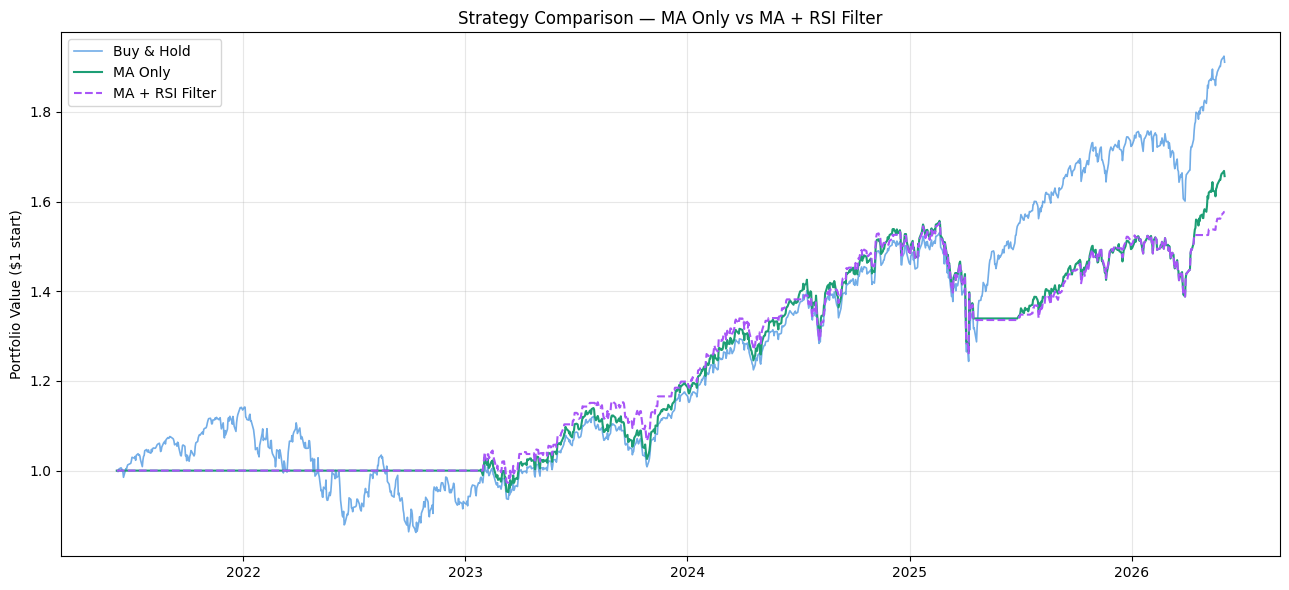

In [7]:
eq_bh   = (1+bh_returns).cumprod()
eq_ma   = (1+ma_returns).cumprod()
eq_comb = (1+comb_returns).cumprod()

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(eq_bh.index,   eq_bh.values,   color="#378ADD", linewidth=1.2, label="Buy & Hold", alpha=0.7)
ax.plot(eq_ma.index,   eq_ma.values,   color="#1D9E75", linewidth=1.5, label="MA Only")
ax.plot(eq_comb.index, eq_comb.values, color="#A855F7", linewidth=1.5, label="MA + RSI Filter", linestyle="--")
ax.set_title("Strategy Comparison — MA Only vs MA + RSI Filter")
ax.set_ylabel("Portfolio Value ($1 start)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Period-by-Period Breakdown
2021–2022 — The strategies' best moment
The flat green and purple lines at 1.00 is the strategy sitting in cash during the 2022 crash. Buy & hold (blue) drops to ~0.85 while both strategies preserve capital entirely. This is the one genuine win for the MA crossover approach — visually the most compelling part of the chart.
2023 — All three converge at 1.00
All lines meet around early 2023 when the golden cross fires and the strategies re-enter the market. 
The cash preservation during 2022 bought protection but not advantage — buy & hold recovered to the same level.
2023–2024 — Parallel climb
All three lines rise together in a tight band. The strategies slightly lag buy & hold but broadly keep pace. Notably, green and purple are nearly indistinguishable here — the RSI filter makes minimal difference during the bull run.
Early 2025 — The sharp drop
All three fall simultaneously to ~1.33. The strategies offer no extra protection here compared to buy & hold — the MA crossover didn't exit fast enough to avoid this drawdown, consistent with the −18.76% max drawdown figure.
2025–2026 — Divergence widens
Buy & hold surges to ~1.91 while MA Only reaches ~1.66 and MA + RSI Filter lags furthest at ~$1.58. The gap that opened in 2022 (strategies in cash, missing some upside) never fully closes.

In [8]:
#Split data and run out-of-sample test
spy = yf.download("SPY", period="5y")["Close"].squeeze()
daily_returns = spy.pct_change().dropna()

# Split point: first 70% of trading days
split = int(len(daily_returns) * 0.70)
split_date = daily_returns.index[split]
print(f"In-sample:     {daily_returns.index[0].date()} to {split_date.date()}")
print(f"Out-of-sample: {split_date.date()} to {daily_returns.index[-1].date()}")

# Compute signals on full data (MAs need full history)
ma50   = spy.rolling(50).mean()
ma200  = spy.rolling(200).mean()
signal = (ma50 > ma200).astype(int).shift(1)
signal = signal.reindex(daily_returns.index).fillna(0)
strat_returns = daily_returns * signal

# Split into periods
is_returns  = strat_returns.iloc[:split]   # in-sample
oos_returns = strat_returns.iloc[split:]   # out-of-sample
is_bh       = daily_returns.iloc[:split]
oos_bh      = daily_returns.iloc[split:]

print("\n--- In-Sample Results ---")
perf(is_returns, "MA Strategy")
perf(is_bh,      "Buy & Hold")

print("\n--- Out-of-Sample Results ---")
perf(oos_returns, "MA Strategy")
perf(oos_bh,      "Buy & Hold")

[*********************100%***********************]  1 of 1 completed

In-sample:     2021-06-07 to 2024-11-29
Out-of-sample: 2024-11-29 to 2026-06-03

--- In-Sample Results ---
MA Strategy               Return:  51.62%  Sharpe: 0.86  MaxDD: -9.97%
Buy & Hold                Return:  49.05%  Sharpe: 0.50  MaxDD: -24.50%

--- Out-of-Sample Results ---
MA Strategy               Return:   9.28%  Sharpe: 0.17  MaxDD: -18.76%
Buy & Hold                Return:  28.21%  Sharpe: 0.77  MaxDD: -18.76%



The in-sample vs out-of-sample test exposes the strategy's core weakness. Strong in-sample results (Sharpe 0.86, beating buy & hold) were largely driven by one well-timed exit during the 2022 crash — remove that event and the edge disappears. Out-of-sample, the strategy delivered only 9.28% vs 28.21% for buy & hold, a near-zero Sharpe of 0.17, and identical max drawdown — meaning it neither kept up with the market nor protected against losses. The strategy's edge is regime-dependent, not robust.



## Week 2 — Strategy Improvement Assessment

### Pitfalls addressed
- Lookahead bias: fixed with .shift(1) in Week 1
- Transaction costs: subtracted directly from returns (drag: X%)
- Generalisation: tested on SPY, QQQ, GLD, TLT

### RSI filter results
Adding the RSI filter (exit when RSI ≥ 70) made performance worse across every metric — return dropped from 65.68% to 57.69%, Sharpe fell from 0.53 to 0.47, and max drawdown was unchanged at −18.76%. The filter added no value because SPY spent extended periods above RSI 70 during the 2023–2024 bull run while continuing to climb, meaning the strategy repeatedly exited profitable uptrends rather than avoiding genuine reversals.

### Out-of-sample test
- In-sample Sharpe:      0.86
- Out-of-sample Sharpe:  0.17
- Verdict: Degraded — the in-sample result was flattered by a single well-timed exit during the 2022 crash. Without a comparable crash in the out-of-sample period, the strategy's lag and missed rallies were fully exposed, delivering only 9.28% vs 28.21% for buy & hold with identical max drawdown.

### What I would improve next
- Optimise RSI threshold — why 70? Testing 60, 65, and 75 may find a level that filters genuine reversals without cutting profitable momentum days
- Add volume filter — only trade crossovers accompanied by above-average volume, which tends to confirm genuine trend changes rather than false signals
- Test on longer history — 5 years captured only one major crash; a 10-year backtest would include more market regimes and give a more honest picture of the strategy's true edge